# Convert CalSim tunnel output to an additional sink

In [1]:
import numpy as np
import pandas as pd
from vtools.functions.unit_conversions import CFS2CMS
from vtools.functions.interpolate import rhistinterp

In [2]:
# load the existing sink file for this grid 

In [3]:
vsinkraw=pd.read_csv('/home/jisrael/BayDeltaSCHISM/data/channel_depletion/vsink_dated.th',sep=r'\s',skiprows=5)
vsinkraw

/scratch/jisrael/job_49754579/ipykernel_2898127/1993064014.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  vsinkraw=pd.read_csv('/home/jisrael/BayDeltaSCHISM/data/channel_depletion/vsink_dated.th',sep=r'\s',skiprows=5)


,datetime,delta_sink_1,delta_sink_3,delta_sink_4,delta_sink_5,delta_sink_6,delta_sink_7,delta_sink_8,delta_sink_9,delta_sink_10,...,suisun_sink_436,suisun_sink_440,suisun_sink_442,suisun_sink_443,suisun_sink_444,suisun_sink_445,suisun_sink_463,suisun_sink_464,suisun_sink_465,suisun_sink_466
0,1999-12-01T00:00,-0.02,-0.01,-0.16,-0.00,-0.00,-0.04,-0.04,-0.00,-0.00,...,-1.03,-0.22,-0.33,-0.41,-0.22,-0.32,-0.12,-0.16,-0.12,-0.12
1,1999-12-02T00:00,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.03,...,-1.03,-0.22,-0.33,-0.41,-0.22,-0.32,-0.12,-0.16,-0.12,-0.12
2,1999-12-03T00:00,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.02,...,-1.01,-0.22,-0.32,-0.40,-0.22,-0.32,-0.12,-0.16,-0.12,-0.12
3,1999-12-04T00:00,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.03,...,-1.02,-0.22,-0.33,-0.40,-0.22,-0.32,-0.12,-0.16,-0.12,-0.12
4,1999-12-05T00:00,-0.02,-0.01,-0.16,-0.00,-0.00,-0.04,-0.04,-0.01,-0.02,...,-1.06,-0.22,-0.33,-0.42,-0.22,-0.32,-0.12,-0.16,-0.12,-0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8700,2023-09-26T00:00,-0.03,-0.01,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,...,-1.04,-0.22,-0.33,-0.40,-0.22,-0.31,-0.12,-0.15,-0.12,-0.12
8701,2023-09-27T00:00,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,...,-1.06,-0.22,-0.33,-0.40,-0.22,-0.31,-0.12,-0.15,-0.12,-0.12
8702,2023-09-28T00:00,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.03,-0.04,...,-1.06,-0.22,-0.33,-0.40,-0.22,-0.31,-0.12,-0.15,-0.12,-0.12
8703,2023-09-29T00:00,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.00,-0.00,...,-1.05,-0.22,-0.33,-0.40,-0.22,-0.31,-0.12,-0.15,-0.12,-0.12


In [4]:
vsink=vsinkraw.copy()

In [5]:
#set the datatime column as a date and set it as index
dtformat = '%Y-%m-%dT%H:%M'
vsink['datetime'] = pd.to_datetime(vsink['datetime'],format=dtformat)
vsink.set_index("datetime",inplace=True)
vsink

,delta_sink_1,delta_sink_3,delta_sink_4,delta_sink_5,delta_sink_6,delta_sink_7,delta_sink_8,delta_sink_9,delta_sink_10,delta_sink_11,...,suisun_sink_436,suisun_sink_440,suisun_sink_442,suisun_sink_443,suisun_sink_444,suisun_sink_445,suisun_sink_463,suisun_sink_464,suisun_sink_465,suisun_sink_466
datetime,,,,,,,,,,,,,,,,,,,,,
1999-12-01,-0.02,-0.01,-0.16,-0.00,-0.00,-0.04,-0.04,-0.00,-0.00,-0.00,...,-1.03,-0.22,-0.33,-0.41,-0.22,-0.32,-0.12,-0.16,-0.12,-0.12
1999-12-02,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.03,-0.03,...,-1.03,-0.22,-0.33,-0.41,-0.22,-0.32,-0.12,-0.16,-0.12,-0.12
1999-12-03,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.02,-0.03,...,-1.01,-0.22,-0.32,-0.40,-0.22,-0.32,-0.12,-0.16,-0.12,-0.12
1999-12-04,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.03,-0.03,...,-1.02,-0.22,-0.33,-0.40,-0.22,-0.32,-0.12,-0.16,-0.12,-0.12
1999-12-05,-0.02,-0.01,-0.16,-0.00,-0.00,-0.04,-0.04,-0.01,-0.02,-0.02,...,-1.06,-0.22,-0.33,-0.42,-0.22,-0.32,-0.12,-0.16,-0.12,-0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-26,-0.03,-0.01,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.05,...,-1.04,-0.22,-0.33,-0.40,-0.22,-0.31,-0.12,-0.15,-0.12,-0.12
2023-09-27,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.06,...,-1.06,-0.22,-0.33,-0.40,-0.22,-0.31,-0.12,-0.15,-0.12,-0.12
2023-09-28,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.03,-0.04,-0.04,...,-1.06,-0.22,-0.33,-0.40,-0.22,-0.31,-0.12,-0.15,-0.12,-0.12


# Now load the csv with the CalSim output

In [6]:
calsim=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/s0065_DWRadapt25_2020LU_DCP_DV_v01_20260119.csv',skiprows=1)
calsim

,B,AWOANN_64_XADV,AWOANN_72_XA1DV,AWOANN_72_XA2DV,AWOANN_72_XA3DV,AWOANN_73_XADV,BANKSEC_MAX14DAY,COREQSACDV,CO_EC_MONTH,C_AMR004,...,S_SLTOT,D_TOTAL,S_RESTOT,S_RESTOT_NOD,DEL_CVP_TOTAL,DEL_CVPSWP_TOTAL,DEL_CVP_PAG_TOTAL,DEL_CVP_PSCEX_TOTAL,DEL_CVP_PRF_TOTAL,AWOANN_ALL_DV
0,C,ANNUAL-APPLIED-WATER,ANNUAL-APPLIED-WATER,ANNUAL-APPLIED-WATER,ANNUAL-APPLIED-WATER,ANNUAL-APPLIED-WATER,SALINITY-APPROX,FLOW,SALINITY,CHANNEL,...,STORAGE-CALC,CHANNEL-CALC,STORAGE-CALC,STORAGE-CALC,DELIVERY-CALC,DELIVERY-CALC,DELIVERY-CALC,DELIVERY-CALC,DELIVERY-CALC,ANNUAL-APPLIED-WATER-CALC
1,D,1MON,1MON,1MON,1MON,1MON,1MON,1MON,1MON,1MON,...,1MON,1MON,1MON,1MON,1MON,1MON,1MON,1MON,1MON,1MON
2,E,L2020A,L2020A,L2020A,L2020A,L2020A,L2020A,L2020A,L2020A,L2020A,...,L2020A,L2020A,L2020A,L2020A,L2020A,L2020A,L2020A,L2020A,L2020A,L2020A
3,F,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER,...,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER,PER-AVER
4,Units,TAF,TAF,TAF,TAF,TAF,UMHOS/CM,CFS,UMHOS/CM,CFS,...,TAF,CFS,TAF,TAF,CFS,CFS,CFS,CFS,CFS,TAF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,2021-05-31,61.750805,138.51753,241.3192,308.2731,76.77681,508.54742,0,3739.8245,781.91187,...,504.10895,2288.7563,8261.744,6460.0337,7224.0083,8723.589,240.16713,6368.3027,173.7901,826.6374
1201,2021-06-30,61.750805,138.51753,241.3192,308.2731,76.77681,364.20575,0,5946.4663,1594.4613,...,366.46716,1100,7435.575,5756.9194,7602.373,9480.15,210.05066,6559.1147,189.55424,826.6374
1202,2021-07-31,61.750805,138.51753,241.3192,308.2731,76.77681,431.5524,0,7917.2427,1776.3175,...,308.42493,3247.6865,6371.686,4800.77,8429.724,10661.579,186.77444,7368.621,160.63132,826.6374
1203,2021-08-31,61.750805,138.51753,241.3192,308.2731,76.77681,445.3066,0,8311.093,1233.4518,...,274.505,2784.1377,5583.0957,4077.9573,6283.5654,7830.568,143.20767,5172.224,338.3393,826.6374


In [7]:
# remove rows 0=4 which are other metadata
calsim=calsim.loc[5:]
calsim

,B,AWOANN_64_XADV,AWOANN_72_XA1DV,AWOANN_72_XA2DV,AWOANN_72_XA3DV,AWOANN_73_XADV,BANKSEC_MAX14DAY,COREQSACDV,CO_EC_MONTH,C_AMR004,...,S_SLTOT,D_TOTAL,S_RESTOT,S_RESTOT_NOD,DEL_CVP_TOTAL,DEL_CVPSWP_TOTAL,DEL_CVP_PAG_TOTAL,DEL_CVP_PSCEX_TOTAL,DEL_CVP_PRF_TOTAL,AWOANN_ALL_DV
5,1921-10-31,52.15505,117.46176,206.69159,265.65402,65.76691,284.73438,0,2173.8489,3303.6338,...,603.1599,2737.8328,9121.925,7453.951,6364.8047,10367.869,2670.8645,1822.311,1536.9402,707.7293
6,1921-11-30,52.15505,117.46176,206.69159,265.65402,65.76691,280.09265,0,1507.7043,1882.8943,...,680.7236,9149.209,8829.637,7140.789,1627.2722,2507.366,239.97198,227.46365,804.61194,707.7293
7,1921-12-31,52.15505,117.46176,206.69159,265.65402,65.76691,265.4556,2632.4326,4198.9585,2034.0022,...,1154.2181,13016.465,9194.232,7437.4624,1307.128,2204.1833,495.41293,90.022415,380.75943,707.7293
8,1922-01-31,52.15505,117.46176,206.69159,265.65402,65.76691,549.89514,0,9957.354,1710.3405,...,1528.9861,7717.2646,9448.877,7586.6973,1221.4944,1828.2247,334.4308,241.92528,354.64185,707.7293
9,1922-02-28,52.15505,117.46176,206.69159,265.65402,65.76691,412.1088,0,3406.2688,6096.8486,...,2039,12102.848,10450.068,8408.837,734.6461,1006.3245,131.13622,34.635178,284.32135,707.7293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,2021-05-31,61.750805,138.51753,241.3192,308.2731,76.77681,508.54742,0,3739.8245,781.91187,...,504.10895,2288.7563,8261.744,6460.0337,7224.0083,8723.589,240.16713,6368.3027,173.7901,826.6374
1201,2021-06-30,61.750805,138.51753,241.3192,308.2731,76.77681,364.20575,0,5946.4663,1594.4613,...,366.46716,1100,7435.575,5756.9194,7602.373,9480.15,210.05066,6559.1147,189.55424,826.6374
1202,2021-07-31,61.750805,138.51753,241.3192,308.2731,76.77681,431.5524,0,7917.2427,1776.3175,...,308.42493,3247.6865,6371.686,4800.77,8429.724,10661.579,186.77444,7368.621,160.63132,826.6374
1203,2021-08-31,61.750805,138.51753,241.3192,308.2731,76.77681,445.3066,0,8311.093,1233.4518,...,274.505,2784.1377,5583.0957,4077.9573,6283.5654,7830.568,143.20767,5172.224,338.3393,826.6374


In [8]:
#excerpt the column we want, set the date as the index 
dformat = '%Y-%m-%d'
tunnel=calsim[['B','C_ISF001_OMR027']]
tunnel['datetime'] = pd.to_datetime(tunnel['B'],format=dformat)
tunnel.set_index("datetime",inplace=True)
#tunnel=tunnel.drop('B')
tunnel

,B,C_ISF001_OMR027
datetime,,
1921-10-31,1921-10-31,0
1921-11-30,1921-11-30,0
1921-12-31,1921-12-31,482.00107
1922-01-31,1922-01-31,1003.3086
1922-02-28,1922-02-28,3538.2517
...,...,...
2021-05-31,2021-05-31,0
2021-06-30,2021-06-30,0
2021-07-31,2021-07-31,0


In [9]:
# Convert from CFS to CMS
tunnel['DCP_CMS']=tunnel['C_ISF001_OMR027'].astype(float) * CFS2CMS
tunnel=tunnel.drop(columns=['B','C_ISF001_OMR027'])
tunnel

,DCP_CMS
datetime,
1921-10-31,0.000000
1921-11-30,0.000000
1921-12-31,13.648750
1922-01-31,28.410536
1922-02-28,100.192131
...,...
2021-05-31,0.000000
2021-06-30,0.000000
2021-07-31,0.000000


In [10]:
# interpolate from monthly to daily, Lily recommended rhistinterp with a p of 2 

In [11]:
######## This version is out of date
# from vtools.data.vtime import parse_interval
# #rhistinterp(ts, interval, **dic)
# intv=parse_interval("1day")
# test=rhistinterp(tunnel, intv, p=2)
# test

In [12]:
tunnel_pi=tunnel.index.to_period(freq='M')
tunnel_pi

PeriodIndex(['1921-10', '1921-11', '1921-12', '1922-01', '1922-02', '1922-03',
             '1922-04', '1922-05', '1922-06', '1922-07',
             ...
             '2020-12', '2021-01', '2021-02', '2021-03', '2021-04', '2021-05',
             '2021-06', '2021-07', '2021-08', '2021-09'],
            dtype='period[M]', name='datetime', length=1200)

In [13]:
tunnel_fix=tunnel.set_index(tunnel_pi)
tunnel_fix

,DCP_CMS
datetime,
1921-10,0.000000
1921-11,0.000000
1921-12,13.648750
1922-01,28.410536
1922-02,100.192131
...,...
2021-05,0.000000
2021-06,0.000000
2021-07,0.000000


In [14]:
# New version:
#rhistinterp(ts, dest, p=2.0, lowbound=None, tolbound=1.0e-3, maxiter=5)
test = rhistinterp(tunnel_fix, 'D', p=2,lowbound=0)
test

,DCP_CMS
1921-10-01,0.000000e+00
1921-10-02,2.572786e-09
1921-10-03,2.573200e-09
1921-10-04,2.573257e-09
1921-10-05,2.573250e-09
...,...
2021-09-27,7.677530e-26
2021-09-28,1.194095e-25
2021-09-29,2.157647e-25
2021-09-30,5.011821e-25


In [15]:
# using p=2 gave negative values, function says it needs to be sufficiently large and between 0 and 20
test2 = rhistinterp(tunnel_fix, 'D', p=20,lowbound=0)
test2

,DCP_CMS
1921-10-01,0.000000e+00
1921-10-02,6.494348e-09
1921-10-03,6.496998e-09
1921-10-04,6.497417e-09
1921-10-05,6.497457e-09
...,...
2021-09-27,5.734839e-29
2021-09-28,9.168698e-29
2021-09-29,1.832962e-28
2021-09-30,5.495389e-28


In [16]:
test2.index[36000]

Timestamp('2020-04-24 00:00:00')

<Axes: >

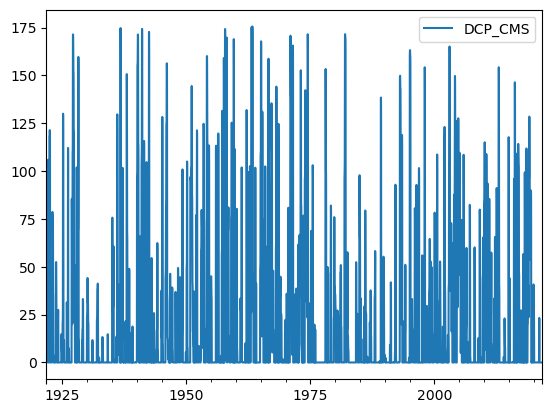

In [17]:
test2.plot()

In [18]:
import matplotlib.pyplot as plt

(np.float64(17757.0), np.float64(18901.0))

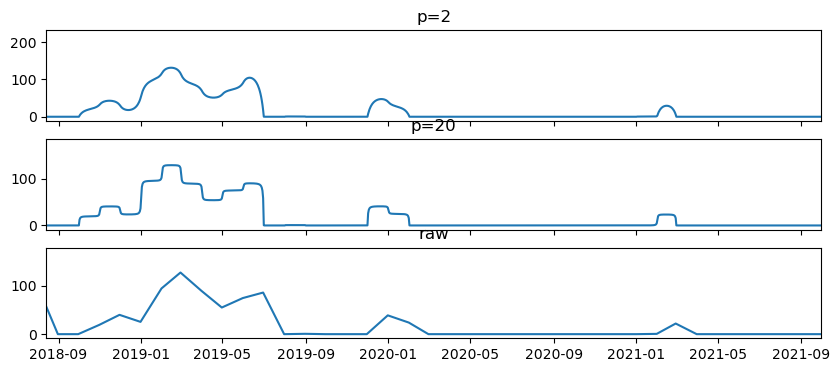

In [19]:
fig, ax = plt.subplots(3,1,sharex=True,figsize=(10,4))
ax[0].plot(test)
ax[0].set_title('p=2')
ax[1].plot(test2)
ax[1].set_title('p=20')
ax[2].plot(tunnel)
ax[2].set_title('raw')
ax[0].set_xlim(pd.to_datetime('2018-08-14 00:00:00'),pd.to_datetime('2021-10-01 00:00:00'))

# Go with p=2

In [20]:
# Flip the sign sink is negative
test['DCP_CMS']=test['DCP_CMS']*-1
test

,DCP_CMS
1921-10-01,-0.000000e+00
1921-10-02,-2.572786e-09
1921-10-03,-2.573200e-09
1921-10-04,-2.573257e-09
1921-10-05,-2.573250e-09
...,...
2021-09-27,-7.677530e-26
2021-09-28,-1.194095e-25
2021-09-29,-2.157647e-25
2021-09-30,-5.011821e-25


In [21]:
#test.to_csv('tunnel_interp_cms.csv')

# EDIT 05/25/2026: split into 12, 8, 4, and 2 sinks
# EDIT 03/21/2026: split the volume into 6 sinks

In [36]:
def split_sink(path2ssin,vsink,dcp_ts,writecsv=0,fname=None):
    #path2ssin is the path to the associated source_sink.in file
    #vsink is the dated dataframe before the dcp sinks are added
    #dcp_ts is the total sink timeseries interpolated to daily in cubic meters per second,
    #negative sign to match the file convention, column name assumed to be 'DCP_CMS'
    sinknames=vsink.columns
    vsink_tunnel=vsink.copy()
    ssin = pd.read_csv(path2ssin, sep=r' ! ',skiprows=1,header=None)
    stoadd=np.array([])
    for s in ssin[1]:
        if 'dcp_sink' in s:
            stoadd=np.append(stoadd,s)
    print(stoadd)
    n=len(stoadd)
    print('Add ' + str(n)+ ' sinks to th file')
    fig, ax = plt.subplots()
    ax.plot(test['DCP_CMS'],label='total withdrawn')
    for x in stoadd:
        vsink_tunnel[x]=dcp_ts['DCP_CMS']/n
        ax.plot(vsink_tunnel[x],label=x)

    ax.legend()
    ax.set_xlim(pd.to_datetime('2018-08-14 00:00:00'),pd.to_datetime('2021-10-01 00:00:00'))
    ax.set_ylim(-150,10)
    # reformat the date
    vsink_tunnel.index=vsink_tunnel.index.strftime('%Y-%m-%dT%H:%M')
    if writecsv>0:
        vsink_tunnel.to_csv(fname,sep=" ")
    return vsink_tunnel

/scratch/jisrael/job_49754579/ipykernel_2898127/1121159445.py:8: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  ssin = pd.read_csv(path2ssin, sep=r' ! ',skiprows=1,header=None)


['dcp_sink_1' 'dcp_sink_2' 'dcp_sink_3' 'dcp_sink_4' 'dcp_sink_5'
 'dcp_sink_6' 'dcp_sink_7' 'dcp_sink_8' 'dcp_sink_9' 'dcp_sink_10'
 'dcp_sink_11' 'dcp_sink_12']
Add 12 sinks to th file


,delta_sink_1,delta_sink_3,delta_sink_4,delta_sink_5,delta_sink_6,delta_sink_7,delta_sink_8,delta_sink_9,delta_sink_10,delta_sink_11,...,dcp_sink_3,dcp_sink_4,dcp_sink_5,dcp_sink_6,dcp_sink_7,dcp_sink_8,dcp_sink_9,dcp_sink_10,dcp_sink_11,dcp_sink_12
datetime,,,,,,,,,,,,,,,,,,,,,
1999-12-01T00:00,-0.02,-0.01,-0.16,-0.00,-0.00,-0.04,-0.04,-0.00,-0.00,-0.00,...,-0.053812,-0.053812,-0.053812,-0.053812,-0.053812,-0.053812,-0.053812,-0.053812,-0.053812,-0.053812
1999-12-02T00:00,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.03,-0.03,...,-0.143424,-0.143424,-0.143424,-0.143424,-0.143424,-0.143424,-0.143424,-0.143424,-0.143424,-0.143424
1999-12-03T00:00,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.02,-0.03,...,-0.219461,-0.219461,-0.219461,-0.219461,-0.219461,-0.219461,-0.219461,-0.219461,-0.219461,-0.219461
1999-12-04T00:00,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.03,-0.03,...,-0.285332,-0.285332,-0.285332,-0.285332,-0.285332,-0.285332,-0.285332,-0.285332,-0.285332,-0.285332
1999-12-05T00:00,-0.02,-0.01,-0.16,-0.00,-0.00,-0.04,-0.04,-0.01,-0.02,-0.02,...,-0.343656,-0.343656,-0.343656,-0.343656,-0.343656,-0.343656,-0.343656,-0.343656,-0.343656,-0.343656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-26T00:00,-0.03,-0.01,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-27T00:00,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-28T00:00,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.03,-0.04,-0.04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


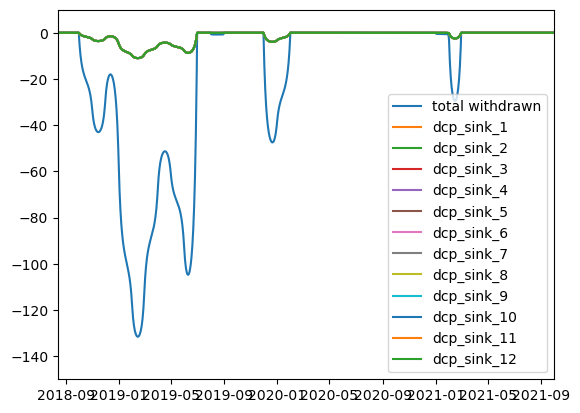

In [40]:
basepath='/home/jisrael/Savio_scratch_back_up/scenario_files/DCP'
split_sink(basepath+'/prepro_out_12/source_sink.in',vsink,test,writecsv=1,fname='vsink_DCP_dated_12.th')

In [24]:
# add this as a delta sink, should be number 356? last on on source_sink.in is delta_sink_355
vsink.columns

Index(['delta_sink_1', 'delta_sink_3', 'delta_sink_4', 'delta_sink_5',
       'delta_sink_6', 'delta_sink_7', 'delta_sink_8', 'delta_sink_9',
       'delta_sink_10', 'delta_sink_11',
       ...
       'suisun_sink_436', 'suisun_sink_440', 'suisun_sink_442',
       'suisun_sink_443', 'suisun_sink_444', 'suisun_sink_445',
       'suisun_sink_463', 'suisun_sink_464', 'suisun_sink_465',
       'suisun_sink_466'],
      dtype='str', length=331)

In [32]:
ssin=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/prepro_out_12/source_sink.in',sep=r' ! ',skiprows=1,header=None)
ssin

/scratch/jisrael/job_49754579/ipykernel_2891107/1939288047.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  ssin=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/prepro_out_12/source_sink.in',sep=r' ! ',skiprows=1,header=None)


,0,1
0,513455,delta_src_1
1,504589,delta_src_3
2,513391,delta_src_4
3,521212,delta_src_5
4,518041,delta_src_6
...,...,...
670,244864,suisun_sink_445
671,347183,suisun_sink_463
672,336167,suisun_sink_464
673,329950,suisun_sink_465


In [33]:
ssin[1]

0          delta_src_1
1          delta_src_3
2          delta_src_4
3          delta_src_5
4          delta_src_6
            ...       
670    suisun_sink_445
671    suisun_sink_463
672    suisun_sink_464
673    suisun_sink_465
674    suisun_sink_466
Name: 1, Length: 675, dtype: str

In [38]:
stoadd=np.array([])
for s in ssin[1]:
    if 'dcp_sink' in s:
        stoadd=np.append(stoadd,s)
print(stoadd)

['dcp_sink_1' 'dcp_sink_2' 'dcp_sink_3' 'dcp_sink_4' 'dcp_sink_5'
 'dcp_sink_6' 'dcp_sink_7' 'dcp_sink_8' 'dcp_sink_9' 'dcp_sink_10'
 'dcp_sink_11' 'dcp_sink_12']


In [22]:
vsink_tunnel=vsink.copy()
vsink_tunnel['dcp_sink_1']=test['DCP_CMS']/6
vsink_tunnel['dcp_sink_2']=test['DCP_CMS']/6
vsink_tunnel['dcp_sink_3']=test['DCP_CMS']/6
vsink_tunnel['dcp_sink_4']=test['DCP_CMS']/6
vsink_tunnel['dcp_sink_5']=test['DCP_CMS']/6
vsink_tunnel['dcp_sink_6']=test['DCP_CMS']/6
vsink_tunnel['dcp_sink_1']

datetime
1999-12-01   -0.107625
1999-12-02   -0.286848
1999-12-03   -0.438922
1999-12-04   -0.570664
1999-12-05   -0.687312
                ...   
2023-09-26         NaN
2023-09-27         NaN
2023-09-28         NaN
2023-09-29         NaN
2023-09-30         NaN
Name: dcp_sink_1, Length: 8705, dtype: float64

(0.0, -150.0)

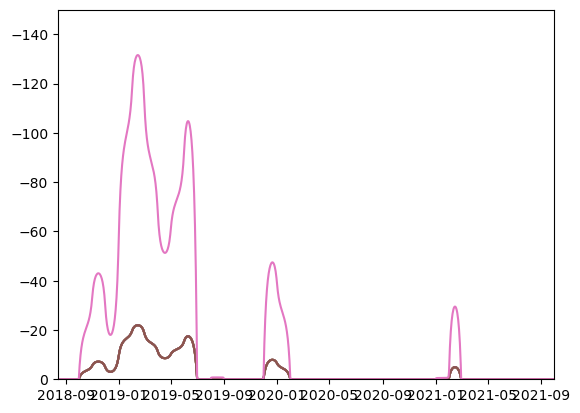

In [26]:
fig, ax = plt.subplots()
ax.plot(vsink_tunnel['dcp_sink_1'])
ax.plot(vsink_tunnel['dcp_sink_2'])
ax.plot(vsink_tunnel['dcp_sink_3'])
ax.plot(vsink_tunnel['dcp_sink_4'])
ax.plot(vsink_tunnel['dcp_sink_5'])
ax.plot(vsink_tunnel['dcp_sink_6'])
ax.plot(test['DCP_CMS'])
ax.set_xlim(pd.to_datetime('2018-08-14 00:00:00'),pd.to_datetime('2021-10-01 00:00:00'))
ax.set_ylim(-150,0)

In [32]:
print(np.min(vsink_tunnel['dcp_sink_6'][pd.to_datetime('2018-08-14 00:00:00'):pd.to_datetime('2021-10-01 00:00:00')]))
print(np.min(test['DCP_CMS'][pd.to_datetime('2018-08-14 00:00:00'):pd.to_datetime('2021-10-01 00:00:00')]))

-21.9299115441415
-131.579469264849


In [24]:
# vsink_tunnel=vsink.copy()
# vsink_tunnel['dcp_sink_1']=test['DCP_CMS']
# vsink_tunnel['dcp_sink_1']

# UPDATE 03/14/2026 need to reformat the date back to dtformat = '%Y-%m-%dT%H:%M'

In [24]:
vsink_tunnel.index.strftime('%Y-%m-%dT%H:%M')

Index(['1999-12-01T00:00', '1999-12-02T00:00', '1999-12-03T00:00',
       '1999-12-04T00:00', '1999-12-05T00:00', '1999-12-06T00:00',
       '1999-12-07T00:00', '1999-12-08T00:00', '1999-12-09T00:00',
       '1999-12-10T00:00',
       ...
       '2023-09-21T00:00', '2023-09-22T00:00', '2023-09-23T00:00',
       '2023-09-24T00:00', '2023-09-25T00:00', '2023-09-26T00:00',
       '2023-09-27T00:00', '2023-09-28T00:00', '2023-09-29T00:00',
       '2023-09-30T00:00'],
      dtype='str', name='datetime', length=8705)

In [25]:
vsink_tunnel.index=vsink_tunnel.index.strftime('%Y-%m-%dT%H:%M')

In [26]:
vsink_tunnel

,delta_sink_1,delta_sink_3,delta_sink_4,delta_sink_5,delta_sink_6,delta_sink_7,delta_sink_8,delta_sink_9,delta_sink_10,delta_sink_11,...,suisun_sink_463,suisun_sink_464,suisun_sink_465,suisun_sink_466,dcp_sink_1,dcp_sink_2,dcp_sink_3,dcp_sink_4,dcp_sink_5,dcp_sink_6
datetime,,,,,,,,,,,,,,,,,,,,,
1999-12-01T00:00,-0.02,-0.01,-0.16,-0.00,-0.00,-0.04,-0.04,-0.00,-0.00,-0.00,...,-0.12,-0.16,-0.12,-0.12,-0.107625,-0.107625,-0.107625,-0.107625,-0.107625,-0.107625
1999-12-02T00:00,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.03,-0.03,...,-0.12,-0.16,-0.12,-0.12,-0.286848,-0.286848,-0.286848,-0.286848,-0.286848,-0.286848
1999-12-03T00:00,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.02,-0.03,...,-0.12,-0.16,-0.12,-0.12,-0.438922,-0.438922,-0.438922,-0.438922,-0.438922,-0.438922
1999-12-04T00:00,-0.02,-0.01,-0.17,-0.01,-0.00,-0.04,-0.04,-0.02,-0.03,-0.03,...,-0.12,-0.16,-0.12,-0.12,-0.570664,-0.570664,-0.570664,-0.570664,-0.570664,-0.570664
1999-12-05T00:00,-0.02,-0.01,-0.16,-0.00,-0.00,-0.04,-0.04,-0.01,-0.02,-0.02,...,-0.12,-0.16,-0.12,-0.12,-0.687312,-0.687312,-0.687312,-0.687312,-0.687312,-0.687312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-26T00:00,-0.03,-0.01,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.05,...,-0.12,-0.15,-0.12,-0.12,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-27T00:00,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.06,...,-0.12,-0.15,-0.12,-0.12,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-28T00:00,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.03,-0.04,-0.04,...,-0.12,-0.15,-0.12,-0.12,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
#write this to a new csv, need to be space separated
vsink_tunnel.to_csv('vsink_DCP_dated.th',sep=" ")